In [1]:
from Trust_Score_Engine import RiskScoreEngine, evaluate_auction_entry

engine = RiskScoreEngine(
    xgb_model_path="final_xgb_shill_model.json",
    xgb_metadata_path="final_model_metadata.json",
    iso_model_path="isolation_forest_model.pkl",
    iso_scaler_path="isolation_forest_scaler.pkl",
    iso_metadata_path="isolation_forest_metadata.json"
)

In [2]:
import pandas as pd
from Trust_Score_Engine import RiskScoreEngine, evaluate_auction_entry

engine = RiskScoreEngine(
    xgb_model_path="final_xgb_shill_model.json",
    xgb_metadata_path="final_model_metadata.json",
    iso_model_path="isolation_forest_model.pkl",
    iso_scaler_path="isolation_forest_scaler.pkl",
    iso_metadata_path="isolation_forest_metadata.json"
)

X_test = pd.read_csv("X_test.csv", index_col=0)
y_test = pd.read_csv("y_test.csv", index_col=0).squeeze()

results = []

for i in range(len(X_test)):

    features = X_test.iloc[[i]]

    result = evaluate_auction_entry(
        engine=engine,
        user_id=f"user_{i}",
        starting_price=100000,
        completed_auctions=1,
        features=features
    )

    results.append({
        "Row": i,
        "Actual Class": int(y_test.iloc[i]),
        "Risk Tier": result["risk_tier"],
        "Risk Score": result["risk_score"],
        "Entry Allowed": result["entry_allowed"],
        "Collateral": (
            result["collateral"]["required_collateral"]
            if result["collateral"] is not None
            else 0
        )
    })

results_df = pd.DataFrame(results)

print(results_df.head())

results_df.to_csv("risk_engine_results.csv", index=False)

print("\nSaved risk_engine_results.csv")

   Row  Actual Class Risk Tier  Risk Score  Entry Allowed  Collateral
0    0             0       low       13.16           True      1000.0
1    1             0       low        4.64           True      1000.0
2    2             0       low        5.12           True      1000.0
3    3             0       low        2.15           True      1000.0
4    4             0       low        4.79           True      1000.0

Saved risk_engine_results.csv


In [4]:
print(results_df["Risk Tier"].value_counts())

Risk Tier
low         843
critical    100
medium        4
high          2
Name: count, dtype: int64


In [6]:
print(pd.crosstab(
    results_df["Risk Tier"],
    results_df["Actual Class"],
    margins=True
))

Actual Class    0    1  All
Risk Tier                  
critical        1   99  100
high            1    1    2
low           842    1  843
medium          4    0    4
All           848  101  949


In [8]:
print(results_df["Risk Score"].describe())

count    949.000000
mean      17.785616
std       26.126512
min        0.000000
25%        4.970000
50%        7.950000
75%       14.100000
max       99.980000
Name: Risk Score, dtype: float64


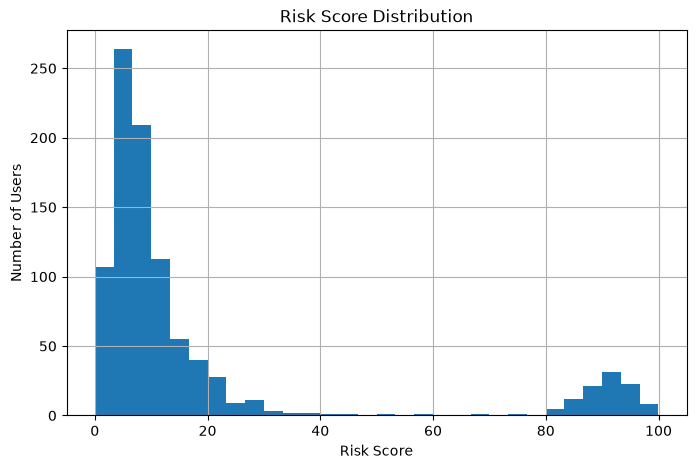

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(results_df["Risk Score"], bins=30)

plt.title("Risk Score Distribution")
plt.xlabel("Risk Score")
plt.ylabel("Number of Users")
plt.grid(True)

plt.savefig("risk_score_distribution.png", dpi=300)

plt.show()

In [10]:
medium = results_df[results_df["Risk Tier"] == "medium"]

print("Medium Risk Users")
print(medium)

Medium Risk Users
     Row  Actual Class Risk Tier  Risk Score  Entry Allowed  Collateral
109  109             0    medium       58.81           True      1500.0
174  174             0    medium       41.67           True      1500.0
433  433             0    medium       52.18           True      1500.0
676  676             0    medium       44.31           True      1500.0


In [11]:
high = results_df[results_df["Risk Tier"] == "high"]

print("High Risk Users")
print(high)

High Risk Users
     Row  Actual Class Risk Tier  Risk Score  Entry Allowed  Collateral
297  297             0      high       74.28           True      2000.0
794  794             1      high       69.13           True      2000.0


In [12]:
critical = results_df[results_df["Risk Tier"] == "critical"]

print("Critical Users")
print(critical.head(20))

Critical Users
     Row  Actual Class Risk Tier  Risk Score  Entry Allowed  Collateral
7      7             1  critical       91.46          False         0.0
9      9             1  critical       89.09          False         0.0
12    12             1  critical       95.17          False         0.0
15    15             1  critical       88.23          False         0.0
16    16             1  critical       89.26          False         0.0
18    18             1  critical       93.49          False         0.0
79    79             1  critical       92.06          False         0.0
89    89             1  critical       81.90          False         0.0
106  106             1  critical       90.55          False         0.0
113  113             1  critical       89.39          False         0.0
121  121             1  critical       81.51          False         0.0
160  160             1  critical       92.48          False         0.0
168  168             1  critical       91.42     